In [2]:
import pandas as pd
activityLogs = pd.read_csv(r'C:\Users\LENOVO\Downloads\ActivityLogs_Regenerated.csv')
subscription = pd.read_csv(r'C:\Users\LENOVO\Downloads\Subscription_Regenerated.csv')
users = pd.read_csv(r'C:\Users\LENOVO\Documents\Internship\Users.csv')

In [1]:
#Merge Login Frequency Counts with Subscription Data

In [5]:
login_counts = (
    activityLogs[activityLogs['Action'] == 'Login']
    .groupby('UserID')
    .size()
    .reset_index(name='Num_Logins')
)

print(login_counts.head())

   UserID  Num_Logins
0       1           5
1       2           3
2       3           2
3       4           4
4       5           3


In [6]:
user_data = login_counts.merge(
    subscription,
    on='UserID',
    how='left'
)

print(user_data.head())

   UserID  Num_Logins PlanType  Renewed
0       1           5  Premium        1
1       2           3     Free        1
2       3           2     Free        1
3       4           4     Free        0
4       5           3     Free        0


In [7]:
print(activityLogs['UserID'].nunique())
print(activityLogs['UserID'].head(20))

5000
0     1833
1     2586
2     3648
3       80
4     4710
5     2224
6     2570
7     1773
8     4519
9     1124
10    3812
11    3475
12    2624
13    1404
14    2579
15     332
16    4749
17    3609
18     740
19    4607
Name: UserID, dtype: int64


In [8]:
users = users.rename(columns={'UserID': 'ID'})

In [47]:
print(users['ID'].head())

0    1
1    2
2    3
3    4
4    5
Name: ID, dtype: int64


In [48]:
print(users['ID'].head())
print(users['ID'].nunique())

0    1
1    2
2    3
3    4
4    5
Name: ID, dtype: int64
5000


In [ ]:
#Generate Correlation Heatmap for 'Logins' vs 'Renewal'

In [9]:
corr_matrix = user_data[['Num_Logins', 'Renewed']].corr()

print(corr_matrix)

            Num_Logins   Renewed
Num_Logins    1.000000  0.005162
Renewed       0.005162  1.000000


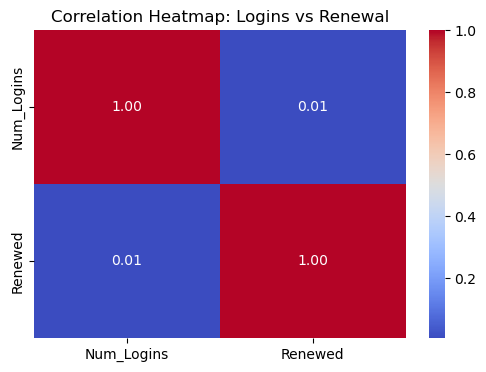

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap: Logins vs Renewal')
plt.show()


In [15]:
#Identify statistically significant usage patterns

#Do Renewed Users Log In More Often?

from scipy.stats import ttest_ind

renewed = user_data[user_data['Renewed'] == 1]['Num_Logins']
not_renewed = user_data[user_data['Renewed'] == 0]['Num_Logins']

t_stat, p_value = ttest_ind(
    renewed,
    not_renewed,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.35367008142730455
P-value: 0.7236046160937782


In [16]:
if p_value < 0.05:
    print("Significant difference found")
else:
    print("No significant difference found")

No significant difference found


In [17]:
#Does Symptom Checker Usage Affect Retention?
symptom_usage = (
    activityLogs[activityLogs['Action'] == 'Symptom_Check']
    .groupby('UserID')
    .size()
    .reset_index(name='Symptom_Usage')
)

In [18]:
symptom_usage = symptom_usage.merge(
    subscription[['UserID','Renewed']],
    on='UserID'
)

In [23]:
renewed = symptom_usage[
    symptom_usage['Renewed']==1
]['Symptom_Usage']

not_renewed = symptom_usage[
    symptom_usage['Renewed']==0
]['Symptom_Usage']

t_stat, p_value = ttest_ind(
    renewed,
    not_renewed,
    equal_var=False
)

print(p_value)

0.1609280815110691


In [26]:
import pandas as pd

sessions = pd.read_csv("sessions.csv")

print(sessions.head())

  user_id        session_start          session_end
0    U001  2026-06-01 09:00:00  2026-06-01 09:18:00
1    U002  2026-06-01 09:05:00  2026-06-01 09:42:00
2    U003  2026-06-01 10:10:00  2026-06-01 10:25:00
3    U004  2026-06-01 10:30:00  2026-06-01 11:15:00
4    U005  2026-06-01 11:00:00  2026-06-01 11:08:00


In [57]:
#Session duration vs renewal

In [27]:
sessions['session_start'] = pd.to_datetime(
    sessions['session_start']
)

sessions['session_end'] = pd.to_datetime(
    sessions['session_end']
)

sessions['SessionMinutes'] = (
    sessions['session_end']
    - sessions['session_start']
).dt.total_seconds() / 60

print(sessions.head())

  user_id       session_start         session_end  SessionMinutes
0    U001 2026-06-01 09:00:00 2026-06-01 09:18:00            18.0
1    U002 2026-06-01 09:05:00 2026-06-01 09:42:00            37.0
2    U003 2026-06-01 10:10:00 2026-06-01 10:25:00            15.0
3    U004 2026-06-01 10:30:00 2026-06-01 11:15:00            45.0
4    U005 2026-06-01 11:00:00 2026-06-01 11:08:00             8.0


In [28]:
sessions['session_start'] = pd.to_datetime(
    sessions['session_start']
)

sessions['session_end'] = pd.to_datetime(
    sessions['session_end']
)

sessions['SessionMinutes'] = (
    sessions['session_end']
    - sessions['session_start']
).dt.total_seconds()/60

In [29]:
session_avg = (
    sessions.groupby('user_id')
    ['SessionMinutes']
    .mean()
    .reset_index()
)

In [60]:
print(session_avg)

  user_id  SessionMinutes
0    U001            27.0
1    U002            30.5
2    U003            32.5
3    U004            43.0
4    U005            42.0


In [30]:
#1. Feature Engineering: Create "Days Since Last Action"

import pandas as pd

# Convert Timestamp column to datetime format
activityLogs['Timestamp'] = pd.to_datetime(activityLogs['Timestamp'])

# Find the latest date in the dataset
latest_date = activityLogs['Timestamp'].max()

# Find the last action date for each user
last_action = activityLogs.groupby('UserID')['Timestamp'].max()

# Convert the result into a DataFrame
last_action = last_action.reset_index()

# Calculate days since the user's last action
last_action['Days_Since_Last_Action'] = (
    latest_date - last_action['Timestamp']
).dt.days

# Display first 5 rows
print(last_action.head())

   UserID           Timestamp  Days_Since_Last_Action
0       1 2025-06-22 14:21:00                       7
1       2 2025-06-01 11:53:00                      28
2       3 2025-06-11 19:35:00                      18
3       4 2025-06-26 16:31:00                       3
4       5 2025-06-21 04:03:00                       8


In [8]:
#Boxplot Analysis of Feature Usage by Churn Status

In [31]:
#count user activity
import pandas as pd

# Count how many actions each user performed
feature_usage = activityLogs.groupby('UserID').size().reset_index(name='Activity_Count')

print(feature_usage.head())

   UserID  Activity_Count
0       1              15
1       2               8
2       3               4
3       4              15
4       5               7


In [32]:
#Merge with subscription data
feature_usage = pd.merge(
    feature_usage,
    subscription[['UserID', 'Renewed']],
    on='UserID'
)

print(feature_usage.head())

   UserID  Activity_Count  Renewed
0       1              15        1
1       2               8        1
2       3               4        1
3       4              15        0
4       5               7        0


In [33]:
#create churn column
feature_usage['Churned'] = 1 - feature_usage['Renewed']

print(feature_usage.head())

   UserID  Activity_Count  Renewed  Churned
0       1              15        1        0
1       2               8        1        0
2       3               4        1        0
3       4              15        0        1
4       5               7        0        1


In [12]:
#Draw boxplot

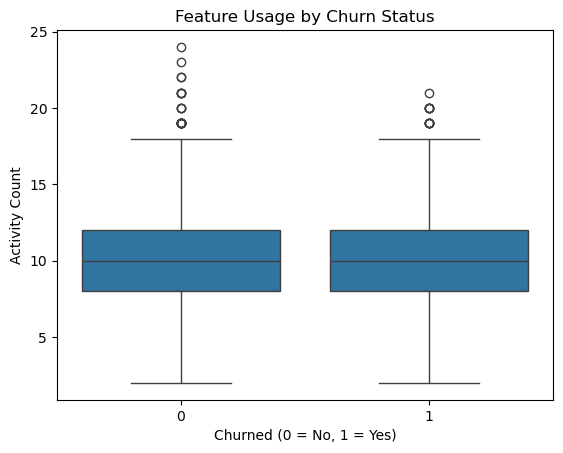

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    x='Churned',
    y='Activity_Count',
    data=feature_usage
)

plt.title("Feature Usage by Churn Status")
plt.xlabel("Churned (0 = No, 1 = Yes)")
plt.ylabel("Activity Count")

plt.show()

In [15]:
#Clean the outliers

In [19]:
import pandas as pd

sessions = pd.read_csv("sessions.csv")

print(sessions.head())


  user_id        session_start          session_end
0    U001  2026-06-01 09:00:00  2026-06-01 09:18:00
1    U002  2026-06-01 09:05:00  2026-06-01 09:42:00
2    U003  2026-06-01 10:10:00  2026-06-01 10:25:00
3    U004  2026-06-01 10:30:00  2026-06-01 11:15:00
4    U005  2026-06-01 11:00:00  2026-06-01 11:08:00


In [35]:
#Convert dates and calculate session duration
sessions['session_start'] = pd.to_datetime(sessions['session_start'])
sessions['session_end'] = pd.to_datetime(sessions['session_end'])

sessions['Session_Duration'] = (
    sessions['session_end'] - sessions['session_start']
).dt.total_seconds() / 60

print(sessions.head())

  user_id       session_start         session_end  SessionMinutes  \
0    U001 2026-06-01 09:00:00 2026-06-01 09:18:00            18.0   
1    U002 2026-06-01 09:05:00 2026-06-01 09:42:00            37.0   
2    U003 2026-06-01 10:10:00 2026-06-01 10:25:00            15.0   
3    U004 2026-06-01 10:30:00 2026-06-01 11:15:00            45.0   
4    U005 2026-06-01 11:00:00 2026-06-01 11:08:00             8.0   

   Session_Duration  
0              18.0  
1              37.0  
2              15.0  
3              45.0  
4               8.0  


In [21]:
#Find Outlier Limits

In [36]:
Q1 = sessions['Session_Duration'].quantile(0.25)
Q3 = sessions['Session_Duration'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: -26.25
Upper Limit: 89.75


In [23]:
#Remove outliers

In [37]:
sessions_clean = sessions[
    (sessions['Session_Duration'] >= lower_limit) &
    (sessions['Session_Duration'] <= upper_limit)
]

print("Original Rows:", len(sessions))
print("Rows After Cleaning:", len(sessions_clean))

Original Rows: 20
Rows After Cleaning: 19


In [38]:
#Compare before and after cleaning
print(sessions['Session_Duration'].describe())

print(sessions_clean['Session_Duration'].describe())

count    20.000000
mean     35.000000
std      23.085653
min       5.000000
25%      17.250000
50%      32.500000
75%      46.250000
max      90.000000
Name: Session_Duration, dtype: float64
count    19.000000
mean     32.105263
std      19.638100
min       5.000000
25%      16.500000
50%      30.000000
75%      45.000000
max      80.000000
Name: Session_Duration, dtype: float64


In [39]:
from sklearn.model_selection import train_test_split

# Features
X = model_data[['Num_Logins', 'Symptom_Check', 'Lab_View']]

# Target
y = model_data['Renewed']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

NameError: name 'model_data' is not defined

In [40]:
print(activityLogs.head())
print(subscription.head())

   LogID  UserID            Action           Timestamp
0      1    1833    Wellness_Track 2025-01-13 11:00:00
1      2    2586     Symptom_Check 2025-02-22 04:49:00
2      3    3648     Symptom_Check 2025-01-12 20:59:00
3      4      80  Teleconsultation 2025-03-24 18:24:00
4      5    4710    Wellness_Track 2025-06-01 07:01:00
   UserID PlanType  Renewed
0       1  Premium        1
1       2     Free        1
2       3     Free        1
3       4     Free        0
4       5     Free        0


In [41]:
import pandas as pd

# Login counts
login_counts = (
    activityLogs[activityLogs['Action'] == 'Login']
    .groupby('UserID')
    .size()
    .reset_index(name='Num_Logins')
)

# Symptom Check counts
symptom_counts = (
    activityLogs[activityLogs['Action'] == 'Symptom_Check']
    .groupby('UserID')
    .size()
    .reset_index(name='Symptom_Check')
)

# Lab View counts
lab_counts = (
    activityLogs[activityLogs['Action'] == 'Lab_View']
    .groupby('UserID')
    .size()
    .reset_index(name='Lab_View')
)

# Merge all tables
model_data = pd.merge(
    login_counts,
    symptom_counts,
    on='UserID',
    how='outer'
)

model_data = pd.merge(
    model_data,
    lab_counts,
    on='UserID',
    how='outer'
)

model_data = pd.merge(
    model_data,
    subscription[['UserID', 'Renewed']],
    on='UserID',
    how='left'
)

# Replace missing values
model_data = model_data.fillna(0)

print(model_data.head())
print(model_data.shape)

   UserID  Num_Logins  Symptom_Check  Lab_View  Renewed
0       1         5.0            4.0       1.0        1
1       2         3.0            1.0       0.0        1
2       3         2.0            1.0       0.0        1
3       4         4.0            2.0       2.0        0
4       5         3.0            1.0       0.0        0
(4988, 5)


In [42]:
X = model_data[['Num_Logins', 'Symptom_Check', 'Lab_View']]

y = model_data['Renewed']

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3990, 3)
(998, 3)


In [44]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [45]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[1 1 1 1 1 1 1 1 1 1]


In [46]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6032064128256514


In [47]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[  0 396]
 [  0 602]]


In [48]:
probabilities = model.predict_proba(X_test)

print(probabilities[:5])

[[0.38461051 0.61538949]
 [0.39812704 0.60187296]
 [0.40743713 0.59256287]
 [0.41419036 0.58580964]
 [0.40652315 0.59347685]]


In [49]:
churn_risk = 1 - probabilities[:, 1]

print(churn_risk[:5])

[0.38461051 0.39812704 0.40743713 0.41419036 0.40652315]


In [50]:
high_risk = X_test.copy()

high_risk['Churn_Risk'] = churn_risk

high_risk_users = high_risk[
    high_risk['Churn_Risk'] > 0.70
]

print(high_risk_users.head())

Empty DataFrame
Columns: [Num_Logins, Symptom_Check, Lab_View, Churn_Risk]
Index: []


In [51]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)

Accuracy: 0.6032064128256514
Precision: 0.6032064128256514
